<a href="https://colab.research.google.com/github/yupAyush/ArticleQNA/blob/main/Predicting_stars_glaxies_quasars.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [65]:
import os
import numpy as np
import pandas as pd
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings("ignore")
from sklearn.metrics import accuracy_score

In [19]:
zip_file_path = "/content/drive/MyDrive/datasets/solan_sky_survey.zip"

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
  zip_ref.extractall()

In [23]:
df = pd.read_csv("/content/Skyserver_SQL2_27_2018 6_51_39 PM.csv")
df.head()


,objid,ra,dec,u,g,r,i,z,run,rerun,camcol,field,specobjid,class,redshift,plate,mjd,fiberid
0,1.237650e+18,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,3.722360e+18,STAR,-0.000009,3306,54922,491
1,1.237650e+18,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,3.638140e+17,STAR,-0.000055,323,51615,541
2,1.237650e+18,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,3.232740e+17,GALAXY,0.123111,287,52023,513
3,1.237650e+18,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,3.722370e+18,STAR,-0.000111,3306,54922,510
4,1.237650e+18,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,3.722370e+18,STAR,0.000590,3306,54922,512


In [34]:

columns_to_drop = ['objid','specobjid']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
print(existing_columns_to_drop)
df.drop(existing_columns_to_drop, axis=1, inplace=True)
df.head(10)
df.shape

[]


(10000, 16)

In [38]:
df.isnull().sum()

,0
ra,0
dec,0
u,0
g,0
r,0
i,0
z,0
run,0
rerun,0
camcol,0


In [42]:
le = LabelEncoder().fit(df["class"])
df["class"]=le.transform(df["class"])
df.head(10)

,ra,dec,u,g,r,i,z,run,rerun,camcol,field,class,redshift,plate,mjd,fiberid
0,183.531326,0.089693,19.47406,17.04240,15.94699,15.50342,15.22531,752,301,4,267,2,-0.000009,3306,54922,491
1,183.598370,0.135285,18.66280,17.21449,16.67637,16.48922,16.39150,752,301,4,267,2,-0.000055,323,51615,541
2,183.680207,0.126185,19.38298,18.19169,17.47428,17.08732,16.80125,752,301,4,268,0,0.123111,287,52023,513
3,183.870529,0.049911,17.76536,16.60272,16.16116,15.98233,15.90438,752,301,4,269,2,-0.000111,3306,54922,510
4,183.883288,0.102557,17.55025,16.26342,16.43869,16.55492,16.61326,752,301,4,269,2,0.000590,3306,54922,512
5,183.847174,0.173694,19.43133,18.46779,18.16451,18.01475,18.04155,752,301,4,269,2,0.000315,324,51666,594
6,183.864379,0.019201,19.38322,17.88995,17.10537,16.66393,16.36955,752,301,4,269,0,0.100242,287,52023,559
7,183.900081,0.187473,18.97993,17.84496,17.38022,17.20673,17.07071,752,301,4,269,2,0.000315,3306,54922,515
8,183.924588,0.097246,17.90616,16.97172,16.67541,16.53776,16.47596,752,301,4,270,2,0.000089,323,51615,595
9,183.973498,0.081626,18.67249,17.71375,17.49362,17.28284,17.22644,752,301,4,270,0,0.040508,288,52000,400


In [51]:
X=df.drop("class",axis=1)
Y=df["class"]

print(Y.head())

print(X.head())

0    2
1    2
2    0
3    2
4    2
Name: class, dtype: int64
           ra       dec         u         g         r         i         z  \
0  183.531326  0.089693  19.47406  17.04240  15.94699  15.50342  15.22531   
1  183.598370  0.135285  18.66280  17.21449  16.67637  16.48922  16.39150   
2  183.680207  0.126185  19.38298  18.19169  17.47428  17.08732  16.80125   
3  183.870529  0.049911  17.76536  16.60272  16.16116  15.98233  15.90438   
4  183.883288  0.102557  17.55025  16.26342  16.43869  16.55492  16.61326   

   run  rerun  camcol  field  redshift  plate    mjd  fiberid  
0  752    301       4    267 -0.000009   3306  54922      491  
1  752    301       4    267 -0.000055    323  51615      541  
2  752    301       4    268  0.123111    287  52023      513  
3  752    301       4    269 -0.000111   3306  54922      510  
4  752    301       4    269  0.000590   3306  54922      512  


In [55]:
scaler = StandardScaler(with_mean=True,with_std=True)
X = scaler.fit_transform(X)
print(X[:10])

[[ 0.16745842 -0.58492272  1.03148637 -0.34855938 -0.83728027 -0.94605772
  -0.99534154 -0.83806089  0.          0.21085172 -0.21763043 -0.36973112
   1.03148936  1.30931064  0.66863177]
 [ 0.16886159 -0.58311429  0.05243046 -0.16653251 -0.15415531 -0.08264457
  -0.02604308 -0.83806089  0.          0.21085172 -0.21763043 -0.36984929
  -0.63621258 -0.87919741  0.91101156]
 [ 0.17057433 -0.58347525  0.92156796  0.86709322  0.59315368  0.44120145
   0.31452753 -0.83806089  0.          0.21085172 -0.21147922 -0.05302706
  -0.65633905 -0.60919097  0.77527888]
 [ 0.17455754 -0.58650069 -1.03063038 -0.81362749 -0.63669227 -0.52660429
  -0.43092107 -0.83806089  0.          0.21085172 -0.20532801 -0.36999261
   1.03148936  1.30931064  0.76073609]
 [ 0.17482457 -0.58441247 -1.29023238 -1.17251944 -0.37676237 -0.02510121
   0.15827647 -0.83806089  0.          0.21085172 -0.20532801 -0.36818949
   1.03148936  1.30931064  0.77043128]
 [ 0.17406874 -0.58159078  0.97991837  1.15913585  1.2396114   1.

In [58]:
x_train,x_test,y_train,y_test= train_test_split(X,Y,test_size=0.3,random_state=128)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(7000, 15)
(7000,)
(3000, 15)
(3000,)


<Axes: xlabel='class', ylabel='count'>

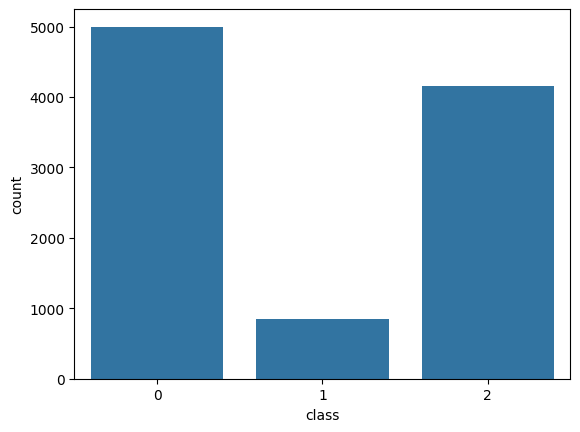

In [61]:
sns.countplot(x=df["class"])

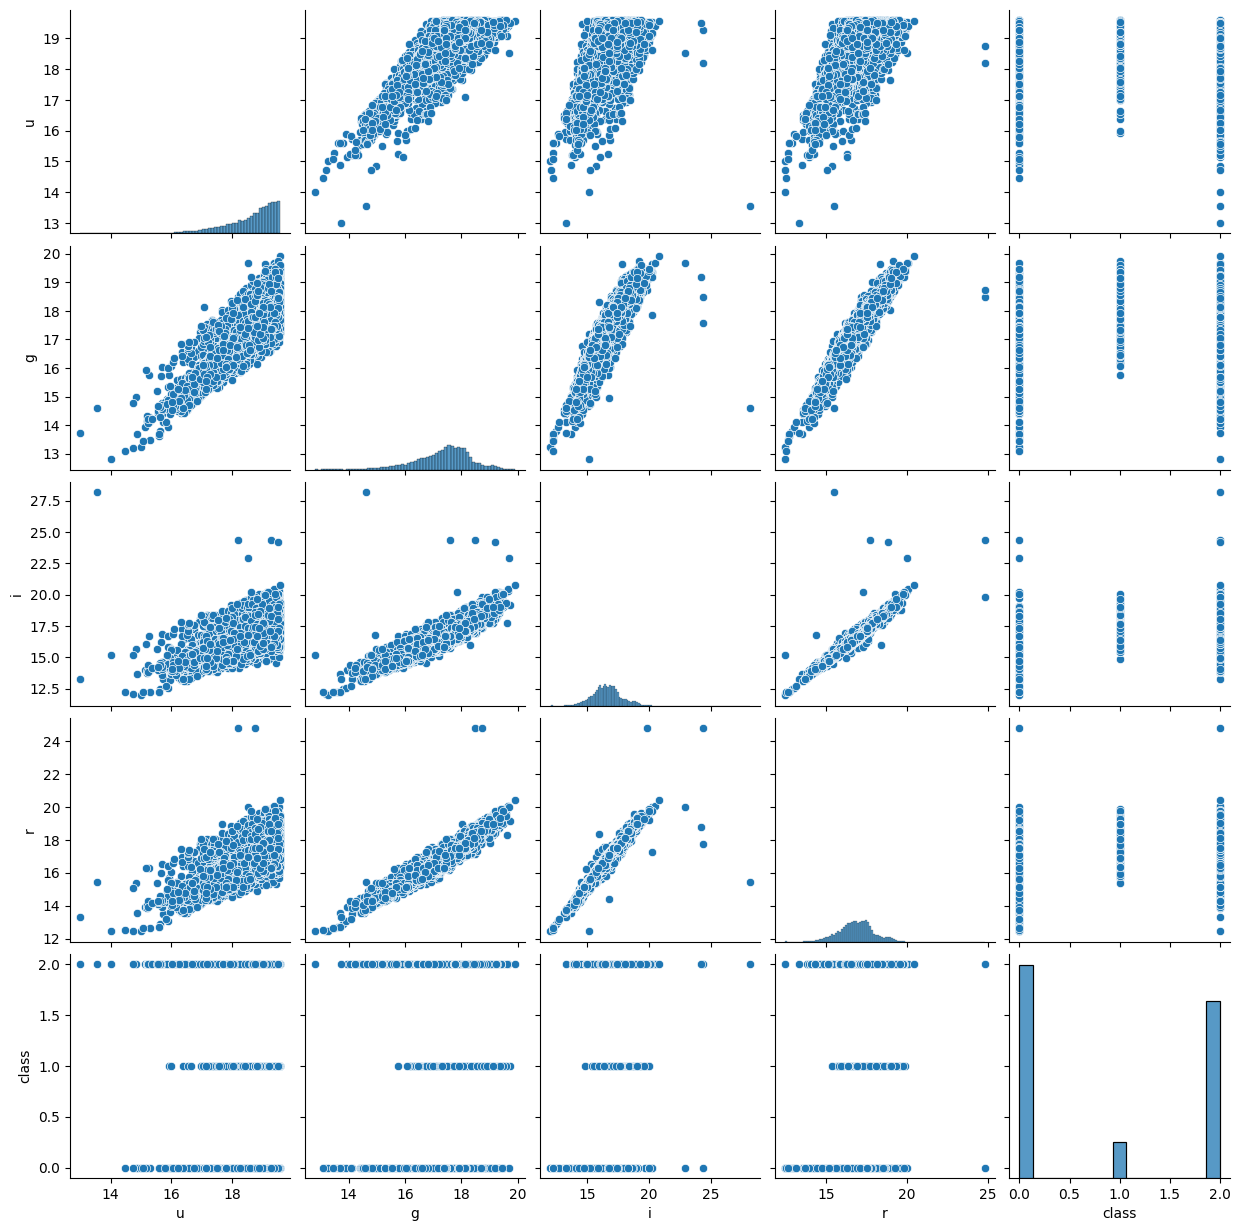

In [62]:
sns.pairplot(df[["u","g","i","r","class"]])

In [67]:
lr = LinearRegression()
lr.fit(x_train,y_train)
x_test_predicted=lr.predict(x_test)
x_test_predicted=np.round(x_test_predicted)
print(x_test_predicted)


[1. 0. 2. ... 0. 2. 0.]


In [68]:
print(accuracy_score(y_test,x_test_predicted)*100)

71.26666666666667
